# Codveda Technologies — Level 2, Task 2
## Decision Trees for Classification

**Dataset:** Iris

### Objectives
1. Preprocess the Iris dataset
2. Train a Decision Tree classifier
3. Tune important hyperparameters using `GridSearchCV`
4. Use cross-validation to select the best model
5. Evaluate the final model using classification metrics
6. Visualize the tree and analyze feature importance

### Professional modeling principle
The test set is kept untouched until the final evaluation. Hyperparameters are selected using cross-validation on the training data only.

## 1. Import Required Libraries

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Load the Dataset



In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

DATA_PATH = "datasets/iris.csv"

df = pd.read_csv("/content/1) iris.csv")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

display(df.head())

Dataset loaded successfully.
Rows: 150
Columns: 5


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Initial Data Inspection

In [3]:
# ============================================================
# 3. INITIAL DATA INSPECTION
# ============================================================

TARGET_COLUMN = "species" if "species" in df.columns else df.columns[-1]

print("Dataset information:")
df.info()

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget distribution:")
display(df[TARGET_COLUMN].value_counts())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing values:


,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0



Duplicate rows:
3

Target distribution:


,count
species,
setosa,50
versicolor,50
virginica,50


## 4. Remove Duplicate Observations

The Iris dataset is small and well known to contain at least one exact duplicate row — worth removing so it doesn't get counted in both the train and test folds by chance.

In [4]:
# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================

duplicates = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

print(f"Duplicate rows removed: {duplicates}")
print(f"New dataset shape: {df.shape}")

Duplicate rows removed: 3
New dataset shape: (147, 5)


## 5. Define Features and Target

Decision trees consume numeric labels, not strings, so the target species names are label-encoded. No scaling is required — trees split on raw thresholds.

In [5]:
# ============================================================
# 5. DEFINE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=[TARGET_COLUMN])
y_raw = df[TARGET_COLUMN]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Classes:", list(label_encoder.classes_))
print("Feature columns:", X.columns.tolist())

Classes: ['setosa', 'versicolor', 'virginica']
Feature columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


## 6. Train/Test Split

A stratified split keeps all three species represented proportionally in both sets.

In [6]:
# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

Training set: (117, 4)
Testing set:  (30, 4)


## 7. Baseline: An Unconstrained Tree

Before tuning, we fit a tree with no depth or leaf-size limit. Left unconstrained, a decision tree keeps splitting until every leaf is pure — memorizing training noise rather than learning generalizable structure. We fit this deliberately so the overfitting signature (a gap between train and test accuracy) is visible before we correct for it.

In [7]:
# ============================================================
# 7. BASELINE UNCONSTRAINED TREE
# ============================================================

baseline_tree = DecisionTreeClassifier(random_state=42)
baseline_tree.fit(X_train, y_train)

train_accuracy = accuracy_score(y_train, baseline_tree.predict(X_train))
test_accuracy = accuracy_score(y_test, baseline_tree.predict(X_test))

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:  {test_accuracy:.4f}")
print(f"Tree depth: {baseline_tree.get_depth()}  |  Leaves: {baseline_tree.get_n_leaves()}")

Train accuracy: 1.0000
Test accuracy:  0.9333
Tree depth: 5  |  Leaves: 8


A large gap between train and test accuracy is the signature of overfitting. On Iris specifically the gap is often small because the classes are well-separated — but the depth/leaf count still shows the tree is more complex than the data needs.

## 8. Hyperparameter Tuning with Grid Search

The hyperparameters are selected using **5-fold cross-validation** on the training set.

We tune:
- `max_depth` — maximum depth of the tree
- `min_samples_split` — minimum samples required to split an internal node
- `min_samples_leaf` — minimum samples required in a leaf

The test set is not used during tuning.

In [8]:
# ============================================================
# 8. GRID SEARCH
# ============================================================

param_grid = {
    "max_depth": [2, 3, 4, 5, 6, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 3]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=False
)

grid_search.fit(X_train, y_train)

print("Best hyperparameters:")
print(grid_search.best_params_)

print(f"\nBest cross-validation F1 (macro) score: {grid_search.best_score_:.4f}")

Best hyperparameters:
{'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best cross-validation F1 (macro) score: 0.9485


## 9. Evaluate the Best Model on the Test Set

In [9]:
# ============================================================
# 9. FINAL TEST EVALUATION
# ============================================================

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision (macro) : {precision:.4f}")
print(f"Recall (macro)    : {recall:.4f}")
print(f"F1 Score (macro)  : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

Accuracy          : 0.9333
Precision (macro) : 0.9333
Recall (macro)    : 0.9333
F1 Score (macro)  : 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 10. Confusion Matrix

,Predicted setosa,Predicted versicolor,Predicted virginica
Actual setosa,10,0,0
Actual versicolor,0,9,1
Actual virginica,0,1,9


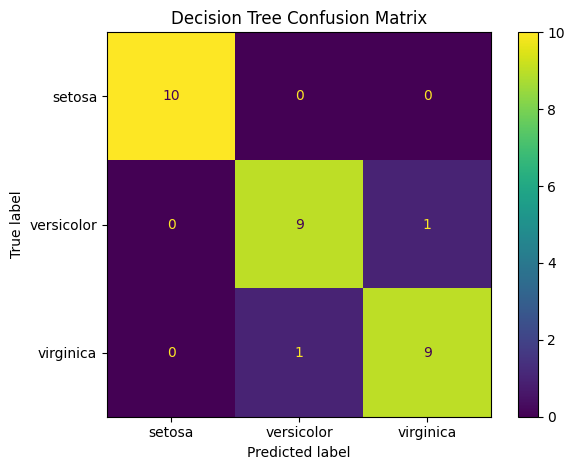

In [10]:
# ============================================================
# 10. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

display(
    pd.DataFrame(
        cm,
        index=[f"Actual {c}" for c in label_encoder.classes_],
        columns=[f"Predicted {c}" for c in label_encoder.classes_]
    )
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
).plot()

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

## 11. Visualize the Tree

This is the whole point of using a decision tree over a black-box model — you can read the decision logic directly.

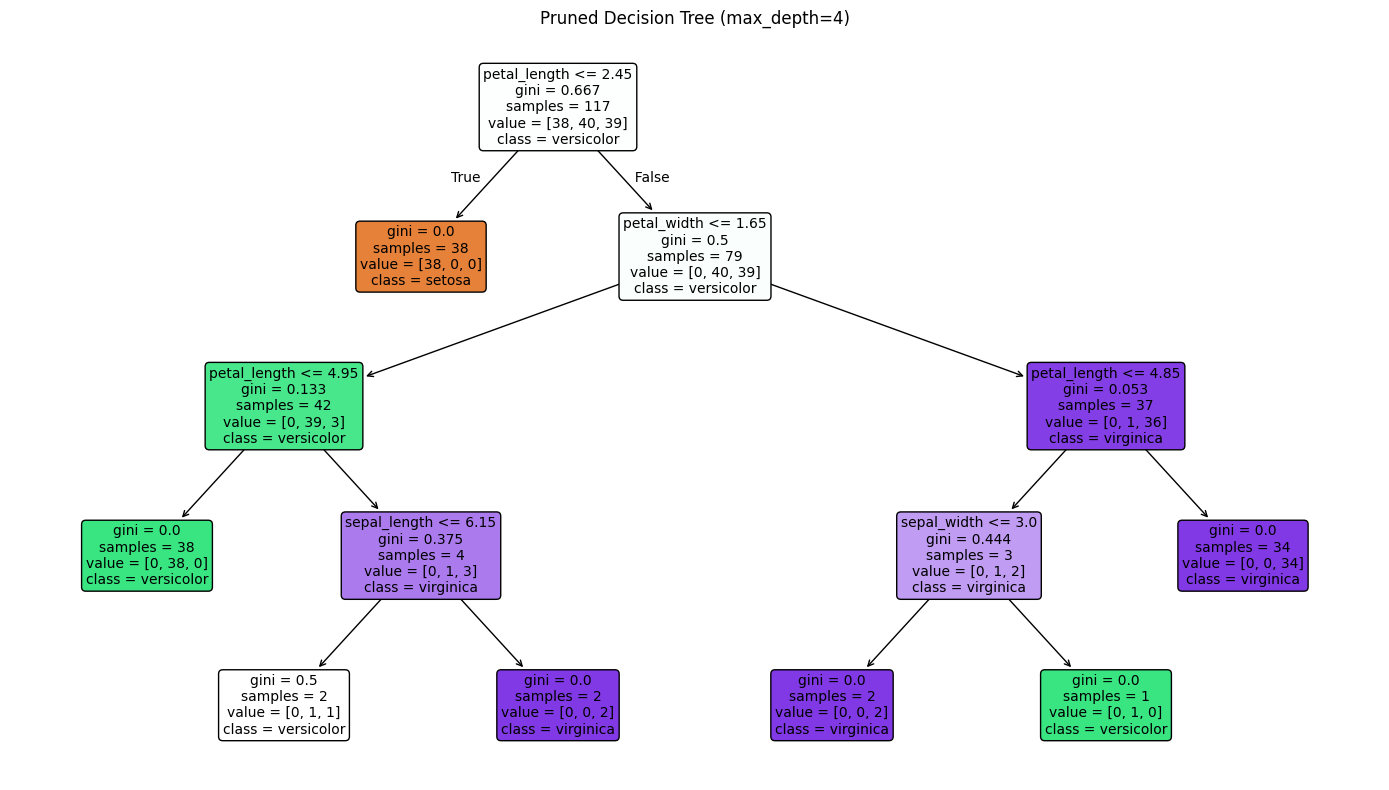

In [11]:
# ============================================================
# 11. TREE VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 8))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Pruned Decision Tree (max_depth={grid_search.best_params_['max_depth']})")
plt.tight_layout()
plt.show()

## 12. Feature Importance

Feature importance measures how much each feature contributes to impurity reduction across the tree's splits.

,Feature,Importance
0,petal_length,0.560816
1,petal_width,0.415369
2,sepal_width,0.017320
3,sepal_length,0.006495


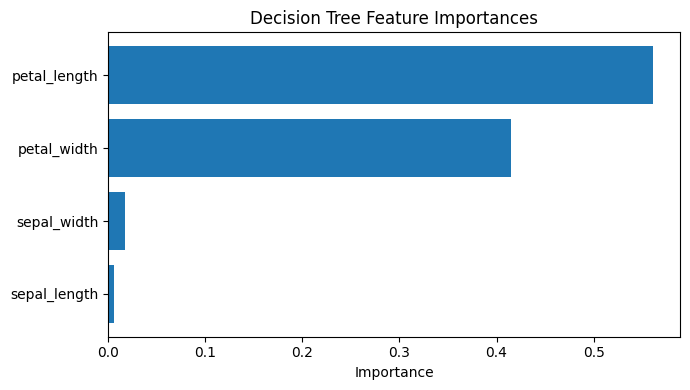

In [12]:
# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

importance_df = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df)

plt.figure(figsize=(7, 4))
plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1]
)
plt.xlabel("Importance")
plt.title("Decision Tree Feature Importances")
plt.tight_layout()
plt.show()

## 13. Final Summary

In [13]:
# ============================================================
# 13. FINAL SUMMARY
# ============================================================

print("=" * 65)
print("LEVEL 2 - TASK 2: DECISION TREE SUMMARY")
print("=" * 65)

print("Best parameters:")
for parameter, value in grid_search.best_params_.items():
    print(f"  {parameter}: {value}")

print(f"\nBest CV F1 (macro) Score: {grid_search.best_score_:.4f}")

print("\nFinal Test Metrics:")
print(f"  Accuracy          : {accuracy:.4f}")
print(f"  Precision (macro) : {precision:.4f}")
print(f"  Recall (macro)    : {recall:.4f}")
print(f"  F1 Score (macro)  : {f1:.4f}")

print("\nFeature importance ranking:")
display(importance_df)

print("=" * 65)

LEVEL 2 - TASK 2: DECISION TREE SUMMARY
Best parameters:
  max_depth: 4
  min_samples_leaf: 1
  min_samples_split: 2

Best CV F1 (macro) Score: 0.9485

Final Test Metrics:
  Accuracy          : 0.9333
  Precision (macro) : 0.9333
  Recall (macro)    : 0.9333
  F1 Score (macro)  : 0.9333

Feature importance ranking:


,Feature,Importance
0,petal_length,0.560816
1,petal_width,0.415369
2,sepal_width,0.017320
3,sepal_length,0.006495
